In [1]:
import os
import sys

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.path.abspath("./"))

print(f"Current work directory: {os.getcwd()}")

Current work directory: C:\Users\yyyyx\Work\OC43_machine_learning\Regression_Modeling_of_OC43_Coronavirus_Viral_Burden_from_Host_Single-cell_Transcriptomes_Using_Explainable_Machine_Learning


In [2]:
from pycaret.regression import setup, compare_models, predict_model, finalize_model, save_model, plot_model, create_model,plot_model, pull, interpret_model, get_config,evaluate_model, tune_model
from sklearn.pipeline import Pipeline
import pandas as pd
from catboost import Pool
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import joblib
import scripts.plotting as pl
import pprint
import json

In [3]:
train_df = pd.read_csv('./CSV/train_df_260421.csv')

In [4]:
test_df = pd.read_csv('./CSV/test_df_260421.csv')

In [5]:
s = setup(
    data=train_df,
    target='target',
    session_id=42,
    fold=5,
    normalize=False,
    verbose=True,
    train_size=0.8
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Regression
3,Original data shape,"(5805, 1658)"
4,Transformed data shape,"(5805, 1658)"
5,Transformed train set shape,"(4644, 1658)"
6,Transformed test set shape,"(1161, 1658)"
7,Numeric features,1657
8,Preprocess,True
9,Imputation type,simple


In [6]:
all_models = compare_models(sort='R2',n_select = 20)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,0.5588,0.5610,0.7485,0.8188,0.1238,0.1093,29.5180
lightgbm,Light Gradient Boosting Machine,0.5814,0.5997,0.7737,0.8064,0.1264,0.1127,2.1000
gbr,Gradient Boosting Regressor,0.6128,0.6619,0.8132,0.7863,0.1323,0.1188,9.1640
br,Bayesian Ridge,0.6385,0.6640,0.8145,0.7855,0.1325,0.1234,0.6860
lar,Least Angle Regression,0.6422,0.6816,0.8252,0.7801,0.1342,0.1247,0.7940
xgboost,Extreme Gradient Boosting,0.6190,0.6857,0.8279,0.7787,0.1344,0.1194,6.7020
et,Extra Trees Regressor,0.6394,0.6979,0.8352,0.7750,0.1355,0.1250,5.9100
rf,Random Forest Regressor,0.6437,0.7179,0.8471,0.7683,0.1370,0.1250,6.6600
omp,Orthogonal Matching Pursuit,0.6875,0.7670,0.8755,0.7524,0.1412,0.1318,0.6360
ada,AdaBoost Regressor,0.7899,0.9081,0.9527,0.7071,0.1556,0.1558,4.0200


In [8]:
for i, model in enumerate(all_models):
    model_name = type(model).__name__
    try:
        params = model.get_params()
        
        print(f"[{i+1}] {model_name} Parameters:")
        pprint.pprint(params)
        print("-" * 60)
        
    except AttributeError:
        print(f"{model_name} does not support the get_params() method.")

[1] CatBoostRegressor Parameters:
{'border_count': 254,
 'loss_function': 'RMSE',
 'random_state': 42,
 'task_type': 'CPU',
 'verbose': False}
------------------------------------------------------------
[2] LGBMRegressor Parameters:
{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}
------------------------------------------------------------
[3] GradientBoostingRegressor Parameters:
{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_sam

In [9]:
for i, model in enumerate(all_models):
    model_name = type(model).__name__
    
    try:
        params = model.get_all_params()
        
        print(f"[{i+1}] {model_name} Parameters:")
        pprint.pprint(params)
        print("-" * 60)
        
    except AttributeError:
        print(f"{model_name} does not support the get_all_params() method.")

[1] CatBoostRegressor Parameters:
{'auto_class_weights': 'None',
 'bayesian_matrix_reg': 0.10000000149011612,
 'best_model_min_trees': 1,
 'boost_from_average': True,
 'boosting_type': 'Plain',
 'bootstrap_type': 'MVS',
 'border_count': 254,
 'classes_count': 0,
 'depth': 6,
 'eval_fraction': 0,
 'eval_metric': 'RMSE',
 'feature_border_type': 'GreedyLogSum',
 'force_unit_auto_pair_weights': False,
 'grow_policy': 'SymmetricTree',
 'iterations': 1000,
 'l2_leaf_reg': 3,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'leaf_estimation_iterations': 1,
 'leaf_estimation_method': 'Newton',
 'learning_rate': 0.052184998989105225,
 'loss_function': 'RMSE',
 'max_leaves': 64,
 'min_data_in_leaf': 1,
 'model_shrink_mode': 'Constant',
 'model_shrink_rate': 0,
 'model_size_reg': 0.5,
 'nan_mode': 'Min',
 'penalties_coefficient': 1,
 'pool_metainfo_options': {'tags': {}},
 'posterior_sampling': False,
 'random_score_type': 'NormalWithModelSizeDecrease',
 'random_seed': 42,
 'random_strength': 

In [10]:
all_models[5]

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [11]:
booster = all_models[5].get_booster()

In [12]:
config = json.loads(booster.save_config())

In [13]:
print(json.dumps(config, indent=4))

{
    "learner": {
        "generic_param": {
            "device": "cpu",
            "fail_on_invalid_gpu_id": "0",
            "n_jobs": "-1",
            "nthread": "-1",
            "random_state": "42",
            "seed": "42",
            "seed_per_iteration": "0",
            "validate_parameters": "1"
        },
        "gradient_booster": {
            "gbtree_model_param": {
                "num_parallel_tree": "1",
                "num_trees": "100"
            },
            "gbtree_train_param": {
                "process_type": "default",
                "tree_method": "auto",
                "updater": "grow_quantile_histmaker",
                "updater_seq": "grow_quantile_histmaker"
            },
            "name": "gbtree",
            "specified_updater": false,
            "tree_train_param": {
                "alpha": "0",
                "cache_opt": "1",
                "colsample_bylevel": "1",
                "colsample_bynode": "1",
                "colsam

In [14]:
trees = booster.get_dump()
print(f"Number of trees actually generated: {len(trees)}")

Number of trees actually generated: 100


In [16]:
joblib.dump(all_models,'./Data/model/All_model_260421.pkl')

['./Data/model/All_model_260421.pkl']

In [17]:
joblib.dump(all_models[0],'./Data/model/All_model_catboost_260421.pkl')

['./Data/model/All_model_catboost_260421.pkl']

In [18]:
tuned_cat = tune_model(all_models[0])

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6368,0.6985,0.8357,0.7795,0.1362,0.1248
1,0.6383,0.7020,0.8378,0.7632,0.1351,0.1217
2,0.6239,0.6891,0.8301,0.7911,0.1383,0.1272
3,0.6016,0.6353,0.7970,0.7979,0.1317,0.1200
4,0.6456,0.7163,0.8463,0.7581,0.1361,0.1234
Mean,0.6293,0.6882,0.8294,0.7780,0.1355,0.1234
Std,0.0155,0.0279,0.0170,0.0154,0.0022,0.0025


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [19]:
final = finalize_model(tuned_cat)

pred = predict_model(final, data=test_df) 
print(pred.head())

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,0.5354,0.5239,0.7238,0.8293,0.1182,0.1042


     SAMD11     CPTP     MXRA8     CCNL2    FNDC10    MMP23B     PEX10  \
0 -0.402294 -0.55236 -0.125468 -0.758331  1.228103 -0.183966 -0.500772   
1 -0.402294 -0.55236 -0.125468  1.092770 -0.531186 -0.183966 -0.500772   
2 -0.402294 -0.55236 -0.125468  0.381066 -0.531186 -0.183966 -0.500772   
3 -0.402294 -0.55236 -0.125468 -0.758331 -0.531186 -0.183966 -0.500772   
4 -0.402294 -0.55236 -0.125468  0.601727 -0.531186 -0.183966 -0.500772   

       HES5  AL139246.5     TP73  ...    FAM50A    PLXNA3      G6PD   MT-ATP8  \
0 -0.075491   -0.227367 -0.22388  ... -1.869142 -0.204827 -0.505786 -0.995051   
1 -0.075491   -0.227367 -0.22388  ... -1.869142 -0.204827  2.999897  1.244259   
2 -0.075491   -0.227367 -0.22388  ... -0.140079 -0.204827 -0.505786  0.589765   
3 -0.075491   -0.227367 -0.22388  ... -0.916474 -0.204827  2.105312 -0.746583   
4 -0.075491   -0.227367 -0.22388  ... -1.869142 -0.204827  2.207960  0.129963   

     MT-CO3    MT-ND4    MT-ND5  AC011043.1    target  prediction_la

In [20]:
joblib.dump(final,'./Data/model/Full_cat_260421.pkl')

['./Data/model/Full_cat_260421.pkl']

In [25]:
best = joblib.load('./Data/model/All_model_catboost_260421.pkl')
final = joblib.load('./Data/model/Full_cat_260421.pkl')

In [26]:
pred_holdout_reg = predict_model(final, data=test_df)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,0.5354,0.5239,0.7238,0.8293,0.1182,0.1042


(<Figure size 1500x1500 with 1 Axes>,
 <Axes: xlabel='Actual value', ylabel='Predicted value'>)

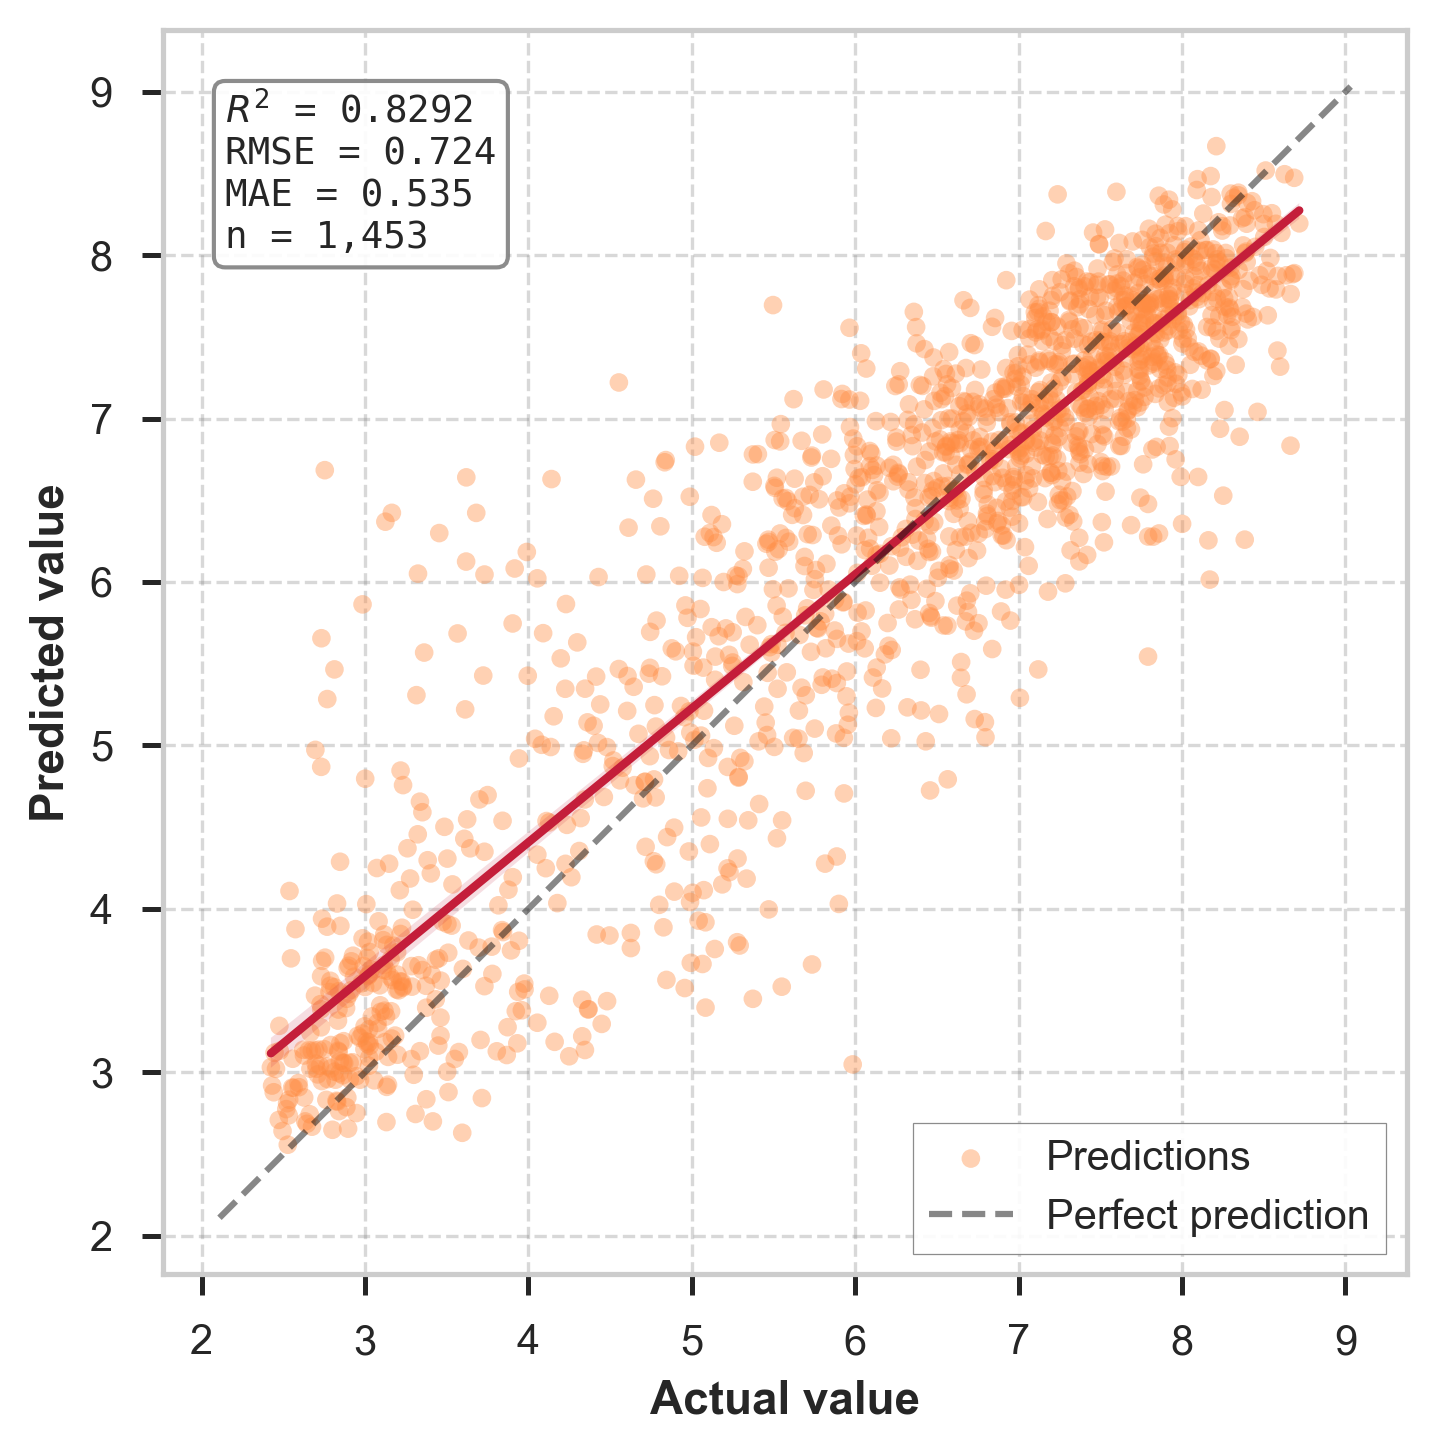

In [27]:
actual = pred_holdout_reg['target']
predicted = pred_holdout_reg['prediction_label']
pl.plot_performance_scatter(y_true=actual, y_pred=predicted,save_path='./Plot/Full_cat_260421.png')

In [28]:
catboost_model = final.steps[-1][1]
preprocessor = Pipeline(final.steps[:-1])

X_raw = train_df.drop(columns=['target'])
y_raw = train_df['target']
feature_names = X_raw.columns.to_list()

X_transformed = preprocessor.transform(X_raw)

if isinstance(X_transformed, pd.DataFrame):
    X_transformed_array = X_transformed.values
else:
    X_transformed_array = X_transformed

X_trans_df = pd.DataFrame(X_transformed, columns=feature_names, index=X_raw.index)

In [29]:
print("🔍 Computing SHAP values...")
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_trans_df)

🔍 Computing SHAP values...


In [30]:
pl.set_publication_style()

Calculating SHAP values...
SHAP beeswarm plot saved to: ./Plot/shap_beeswarm_pub_260421
Feature importance plot saved to: ./Plot/feature_importance_pub_260421


(<Figure size 2400x1500 with 1 Axes>,
 <Axes: title={'center': 'Top 10 Feature Importance'}, xlabel='Feature Importance'>)

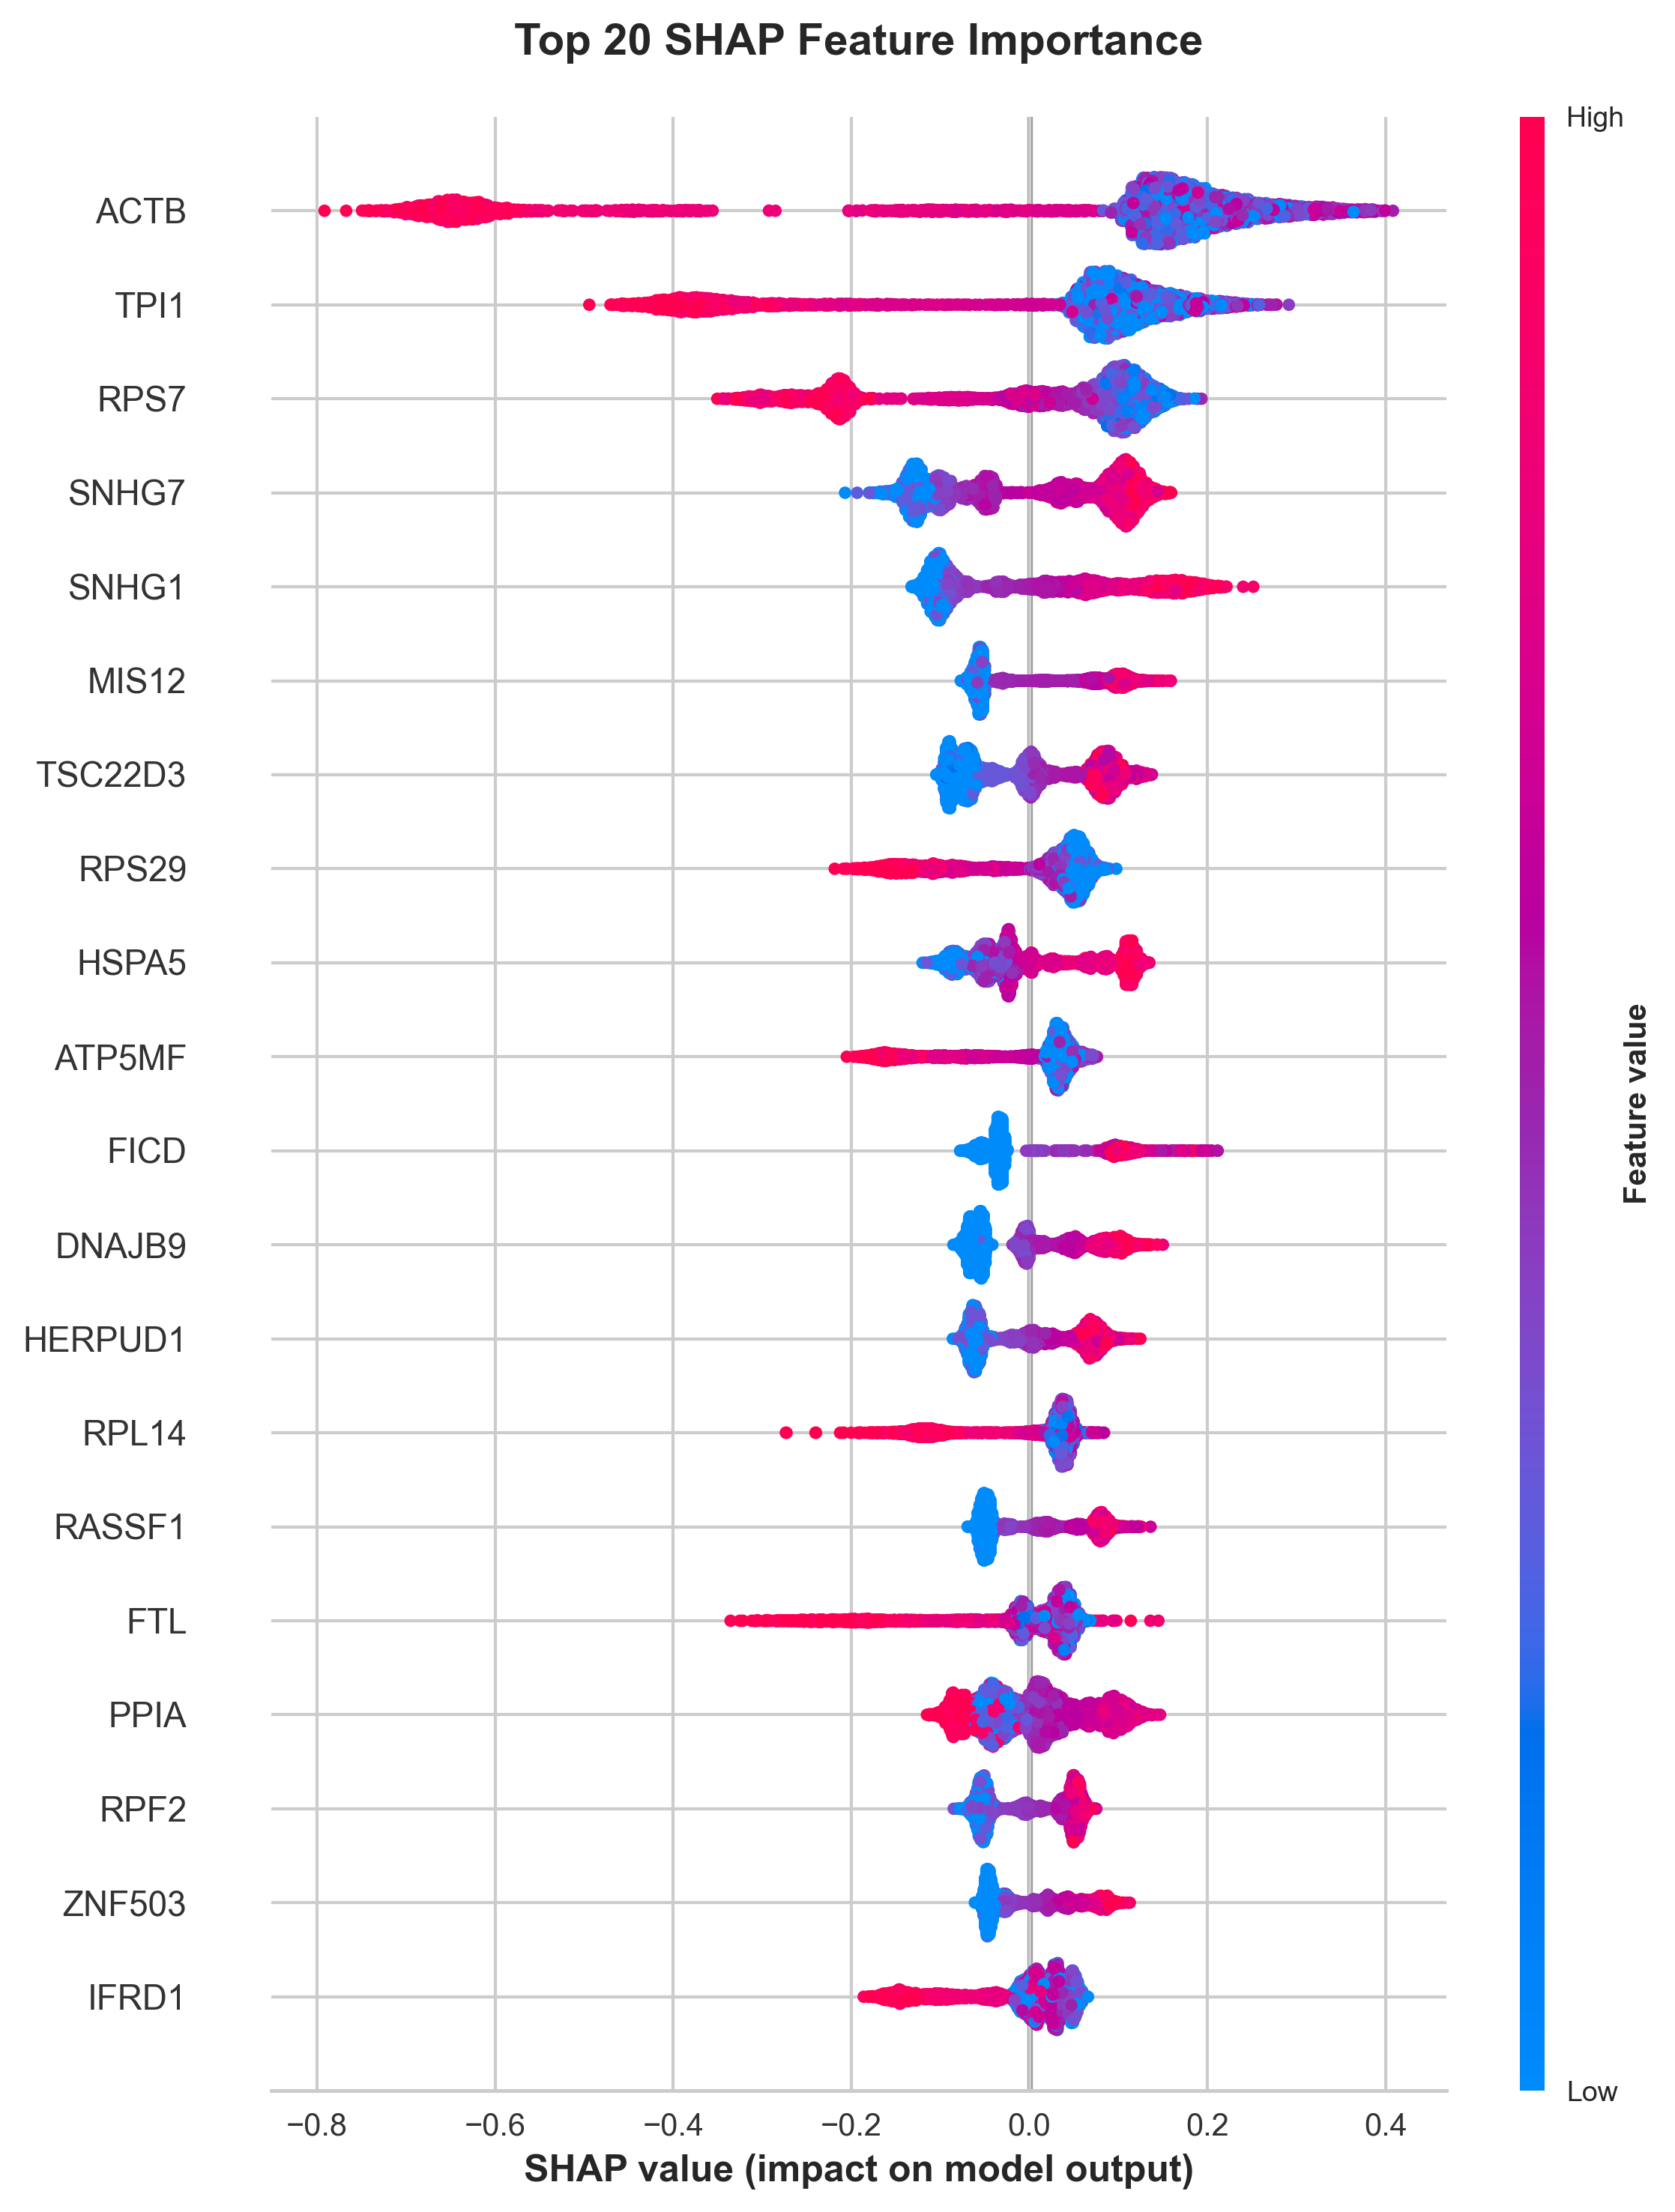

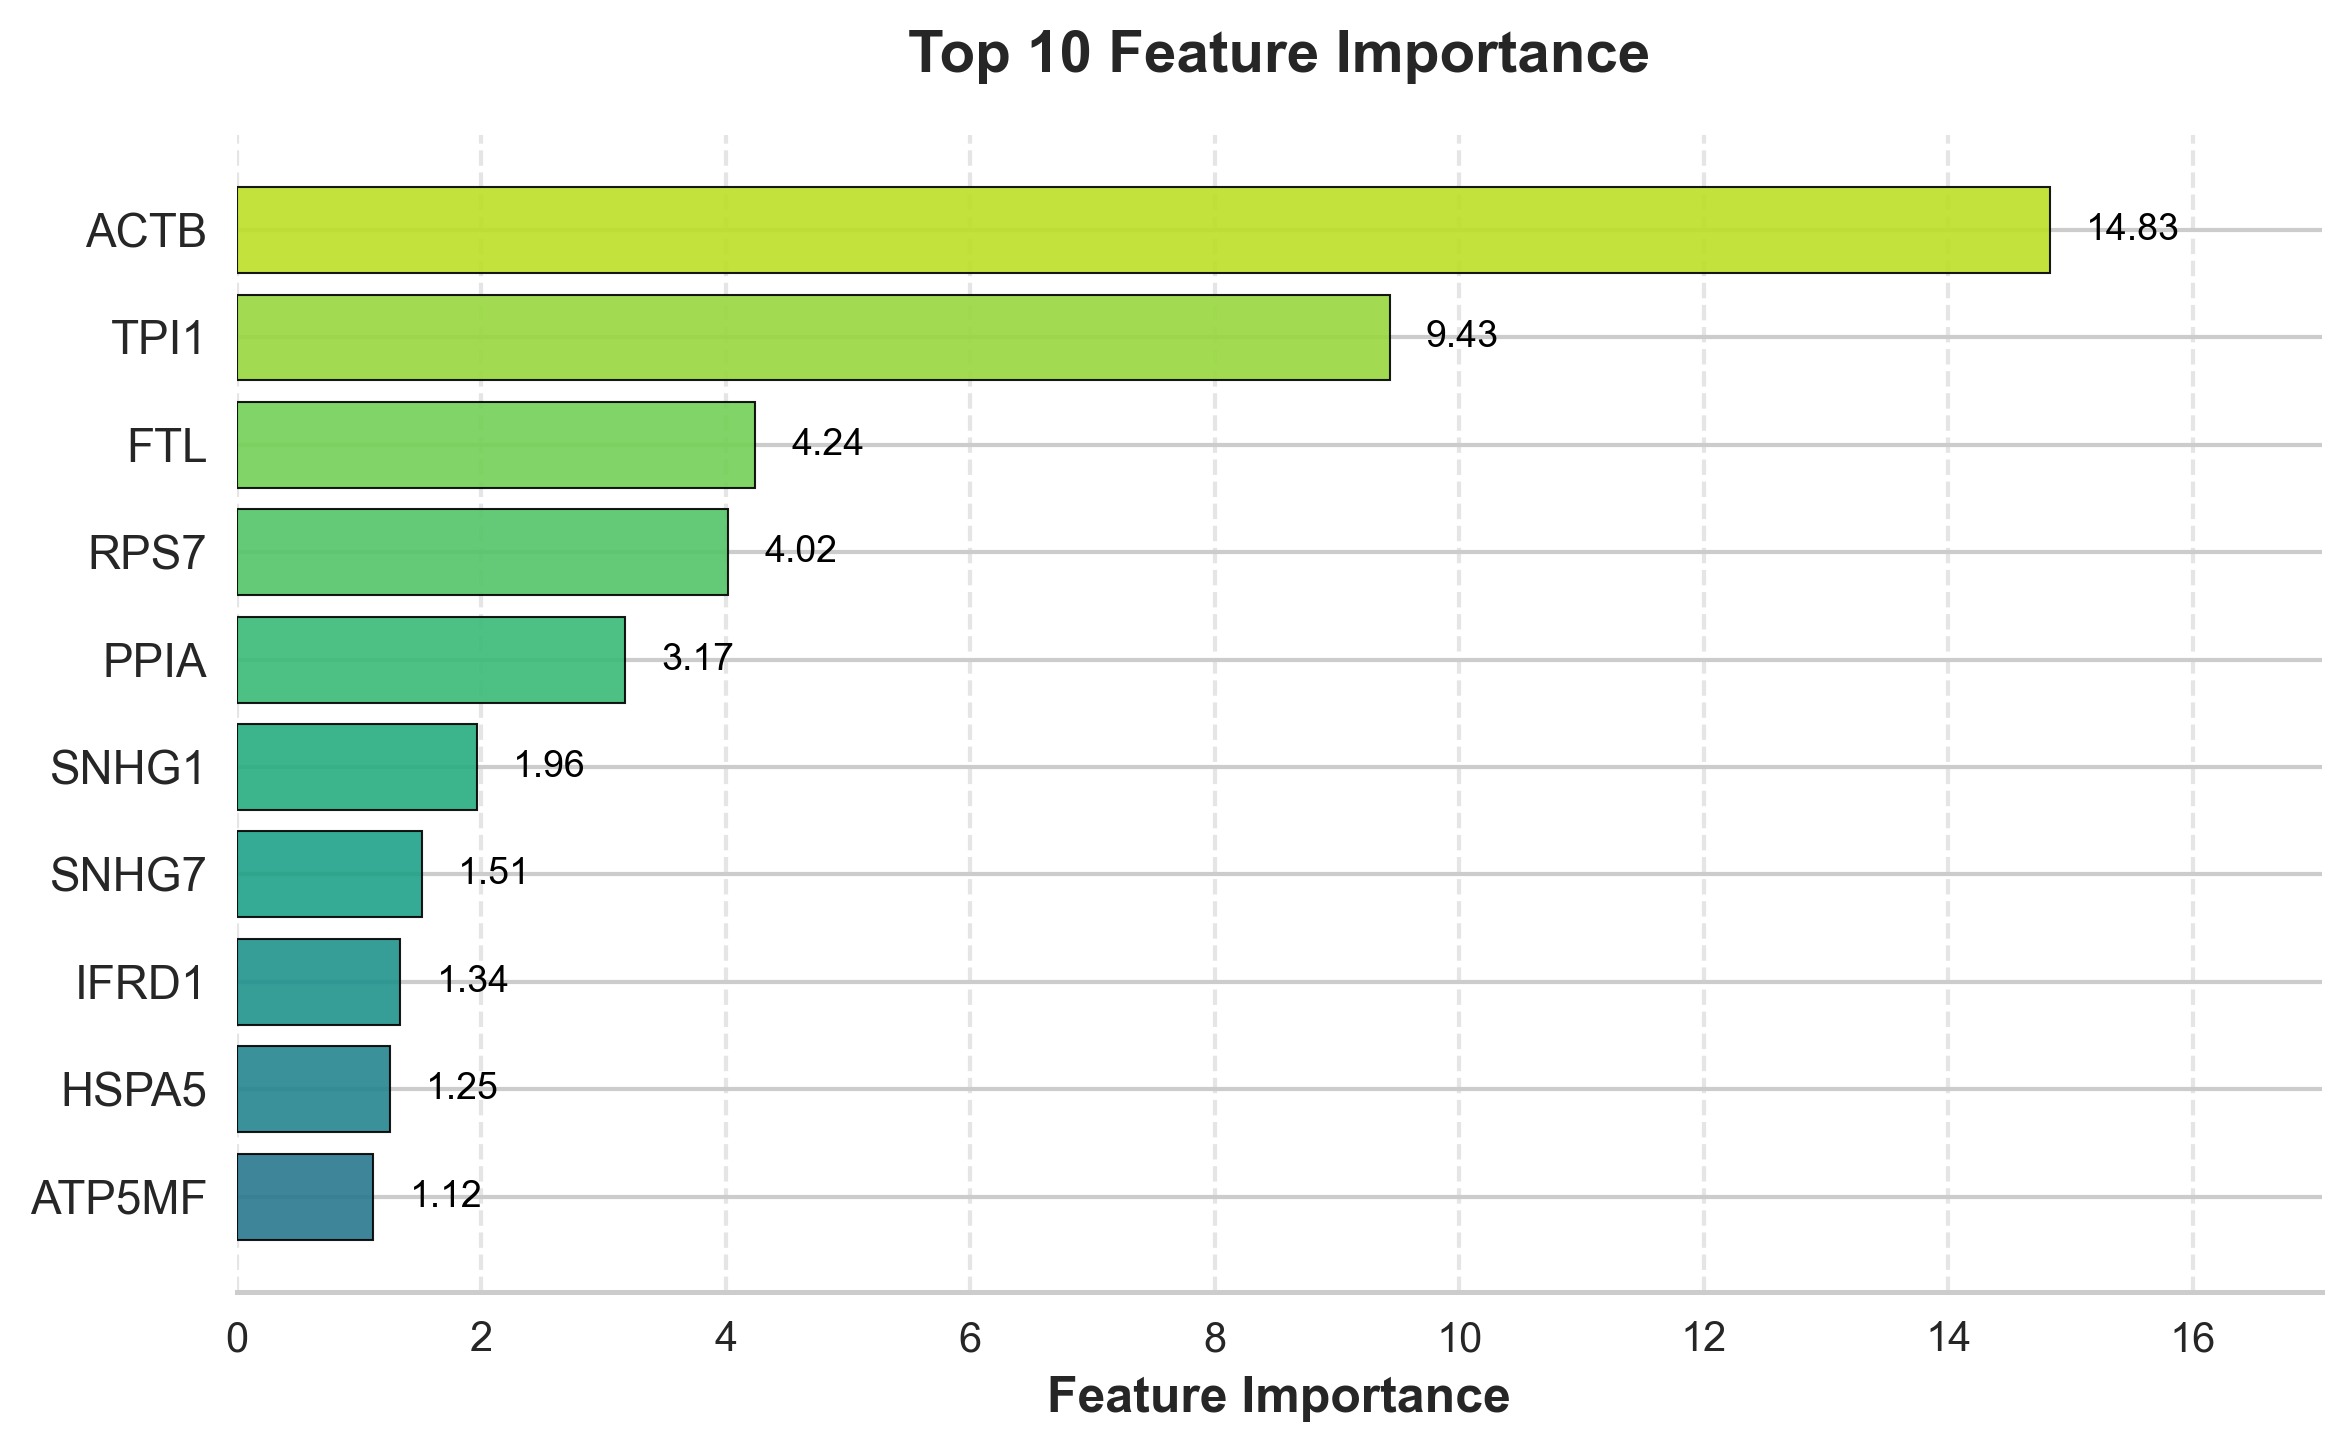

In [31]:
pl.plot_shap_beeswarm(
    model=catboost_model, 
    X_train=X_trans_df, 
    top_k=20, 
    save_path='./Plot/shap_beeswarm_pub_260421'
)

pl.plot_feature_importance(
    model=catboost_model, 
    feature_names=X_trans_df.columns, 
    top_k=10, 
    save_path='./Plot/feature_importance_pub_260421'
)

Custom SHAP plot saved to: ./Plot/Figure1_Panel_D_SHAP_260421


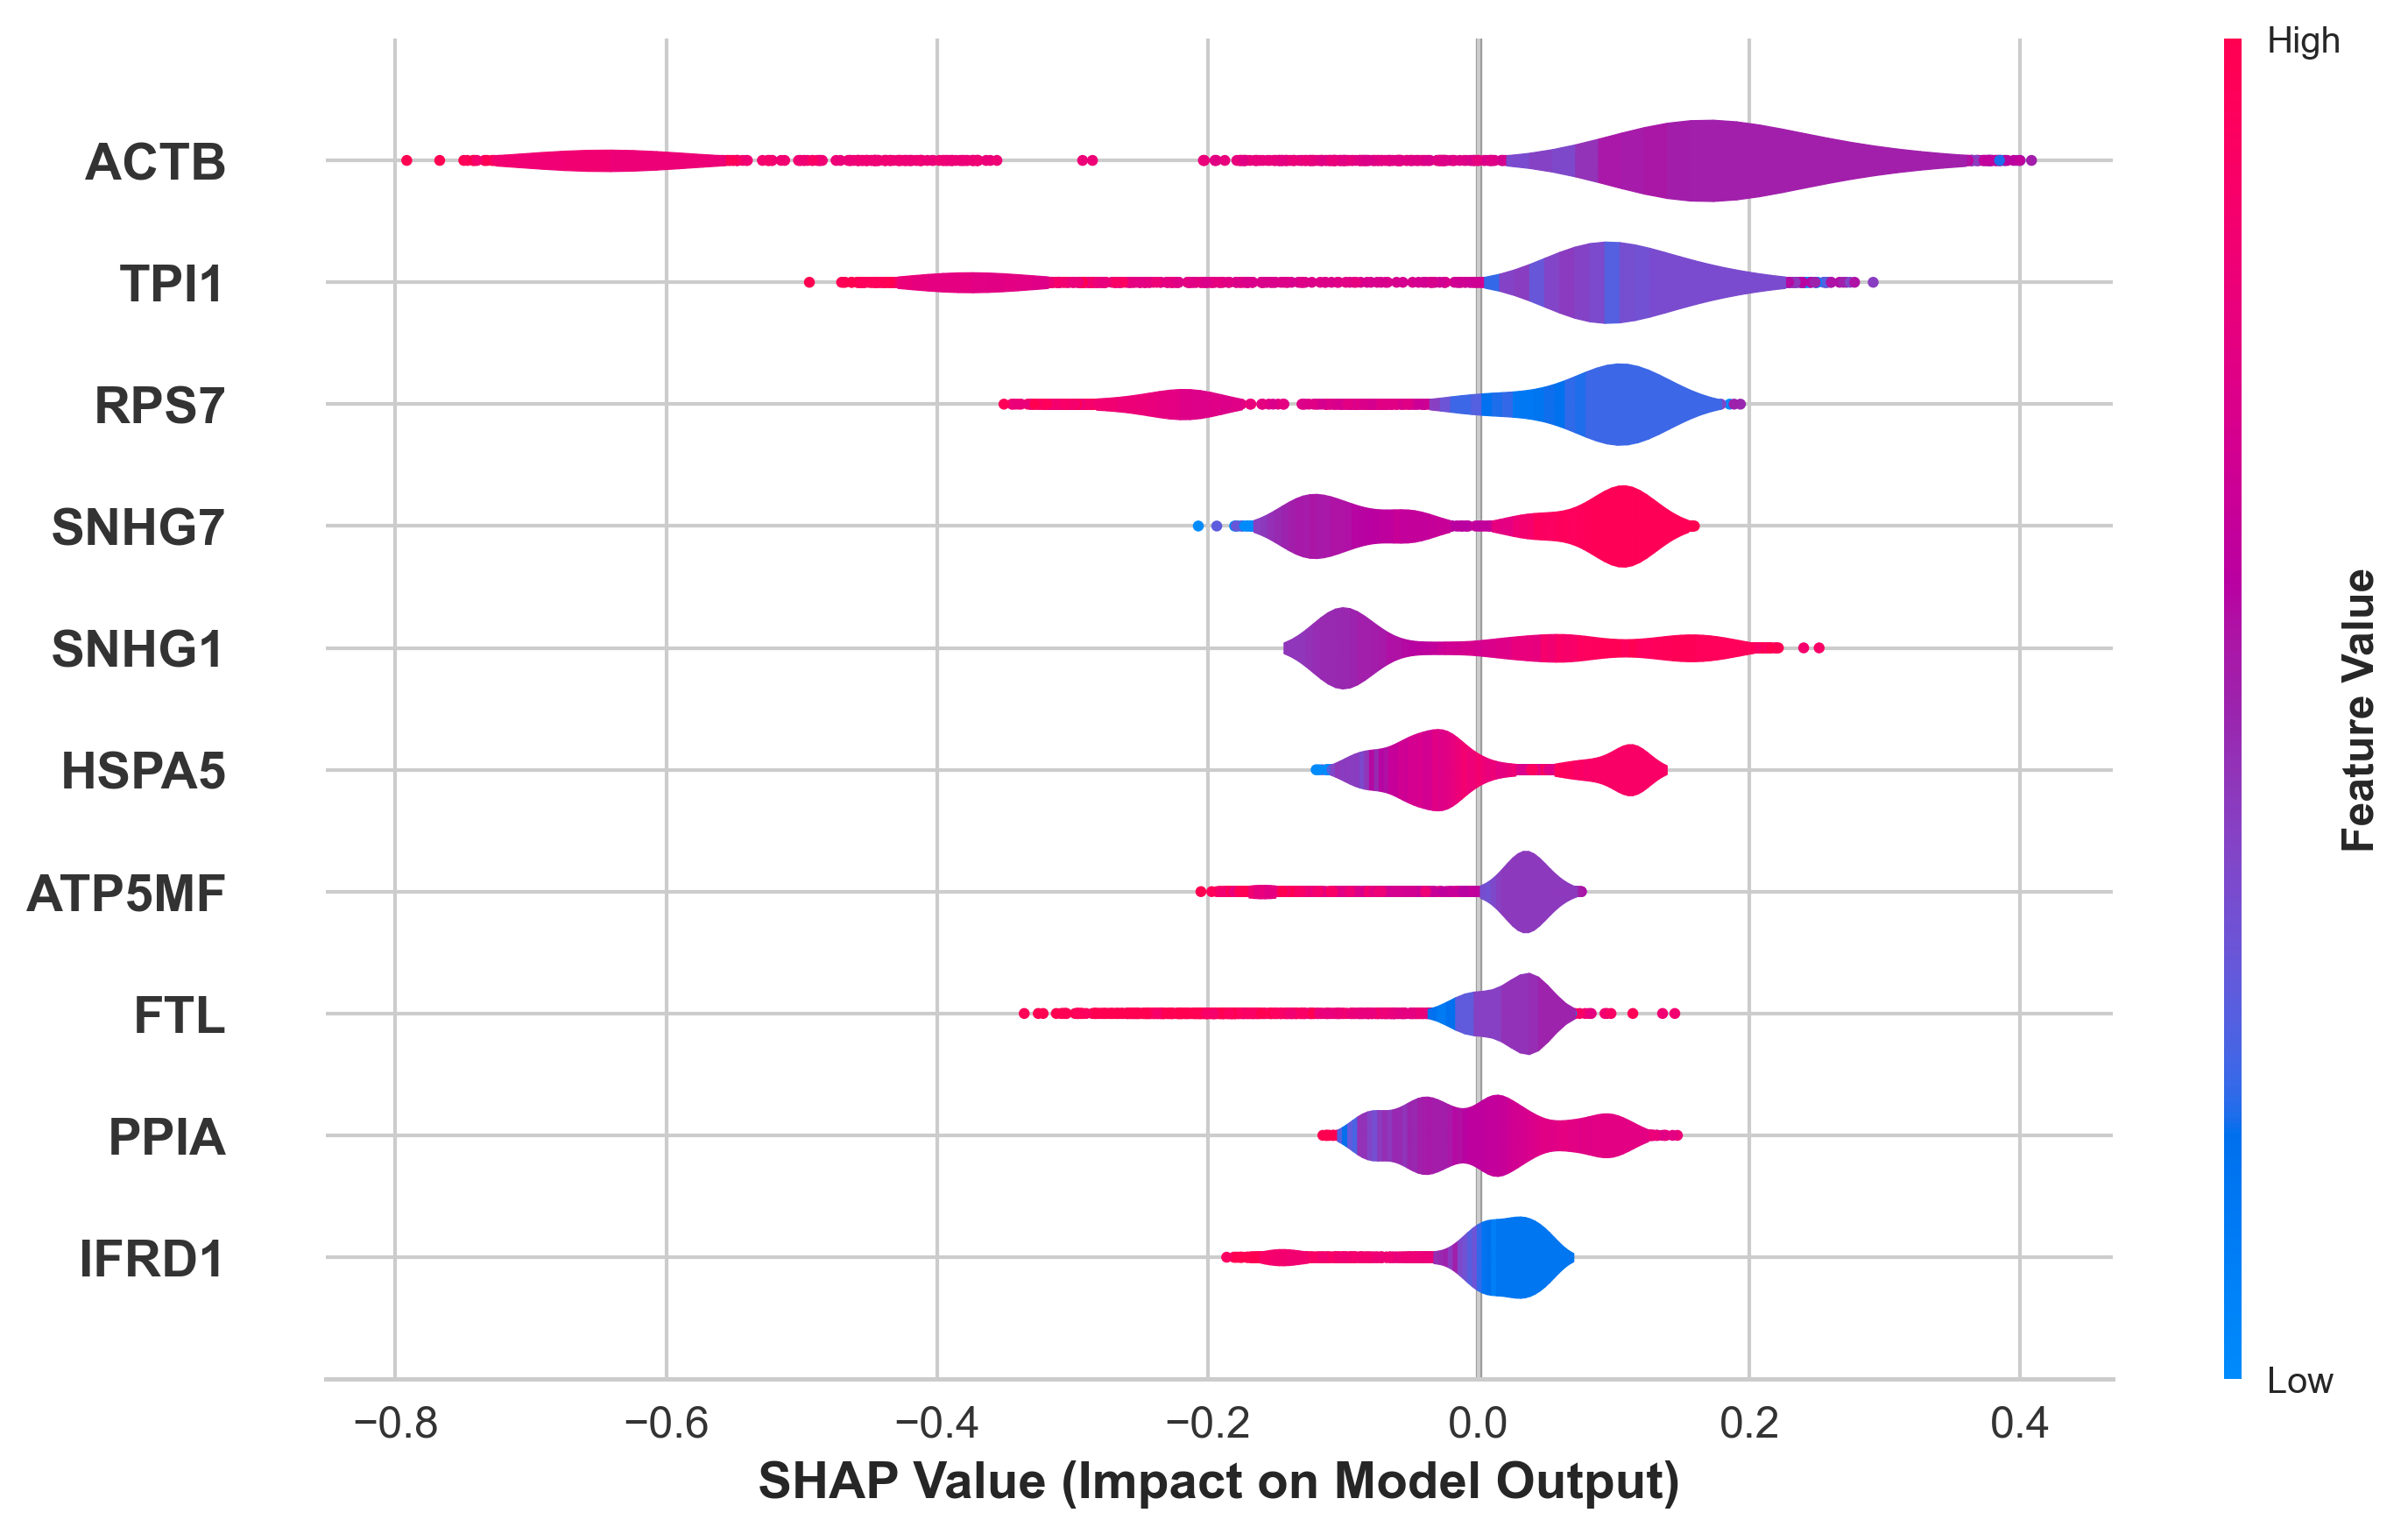

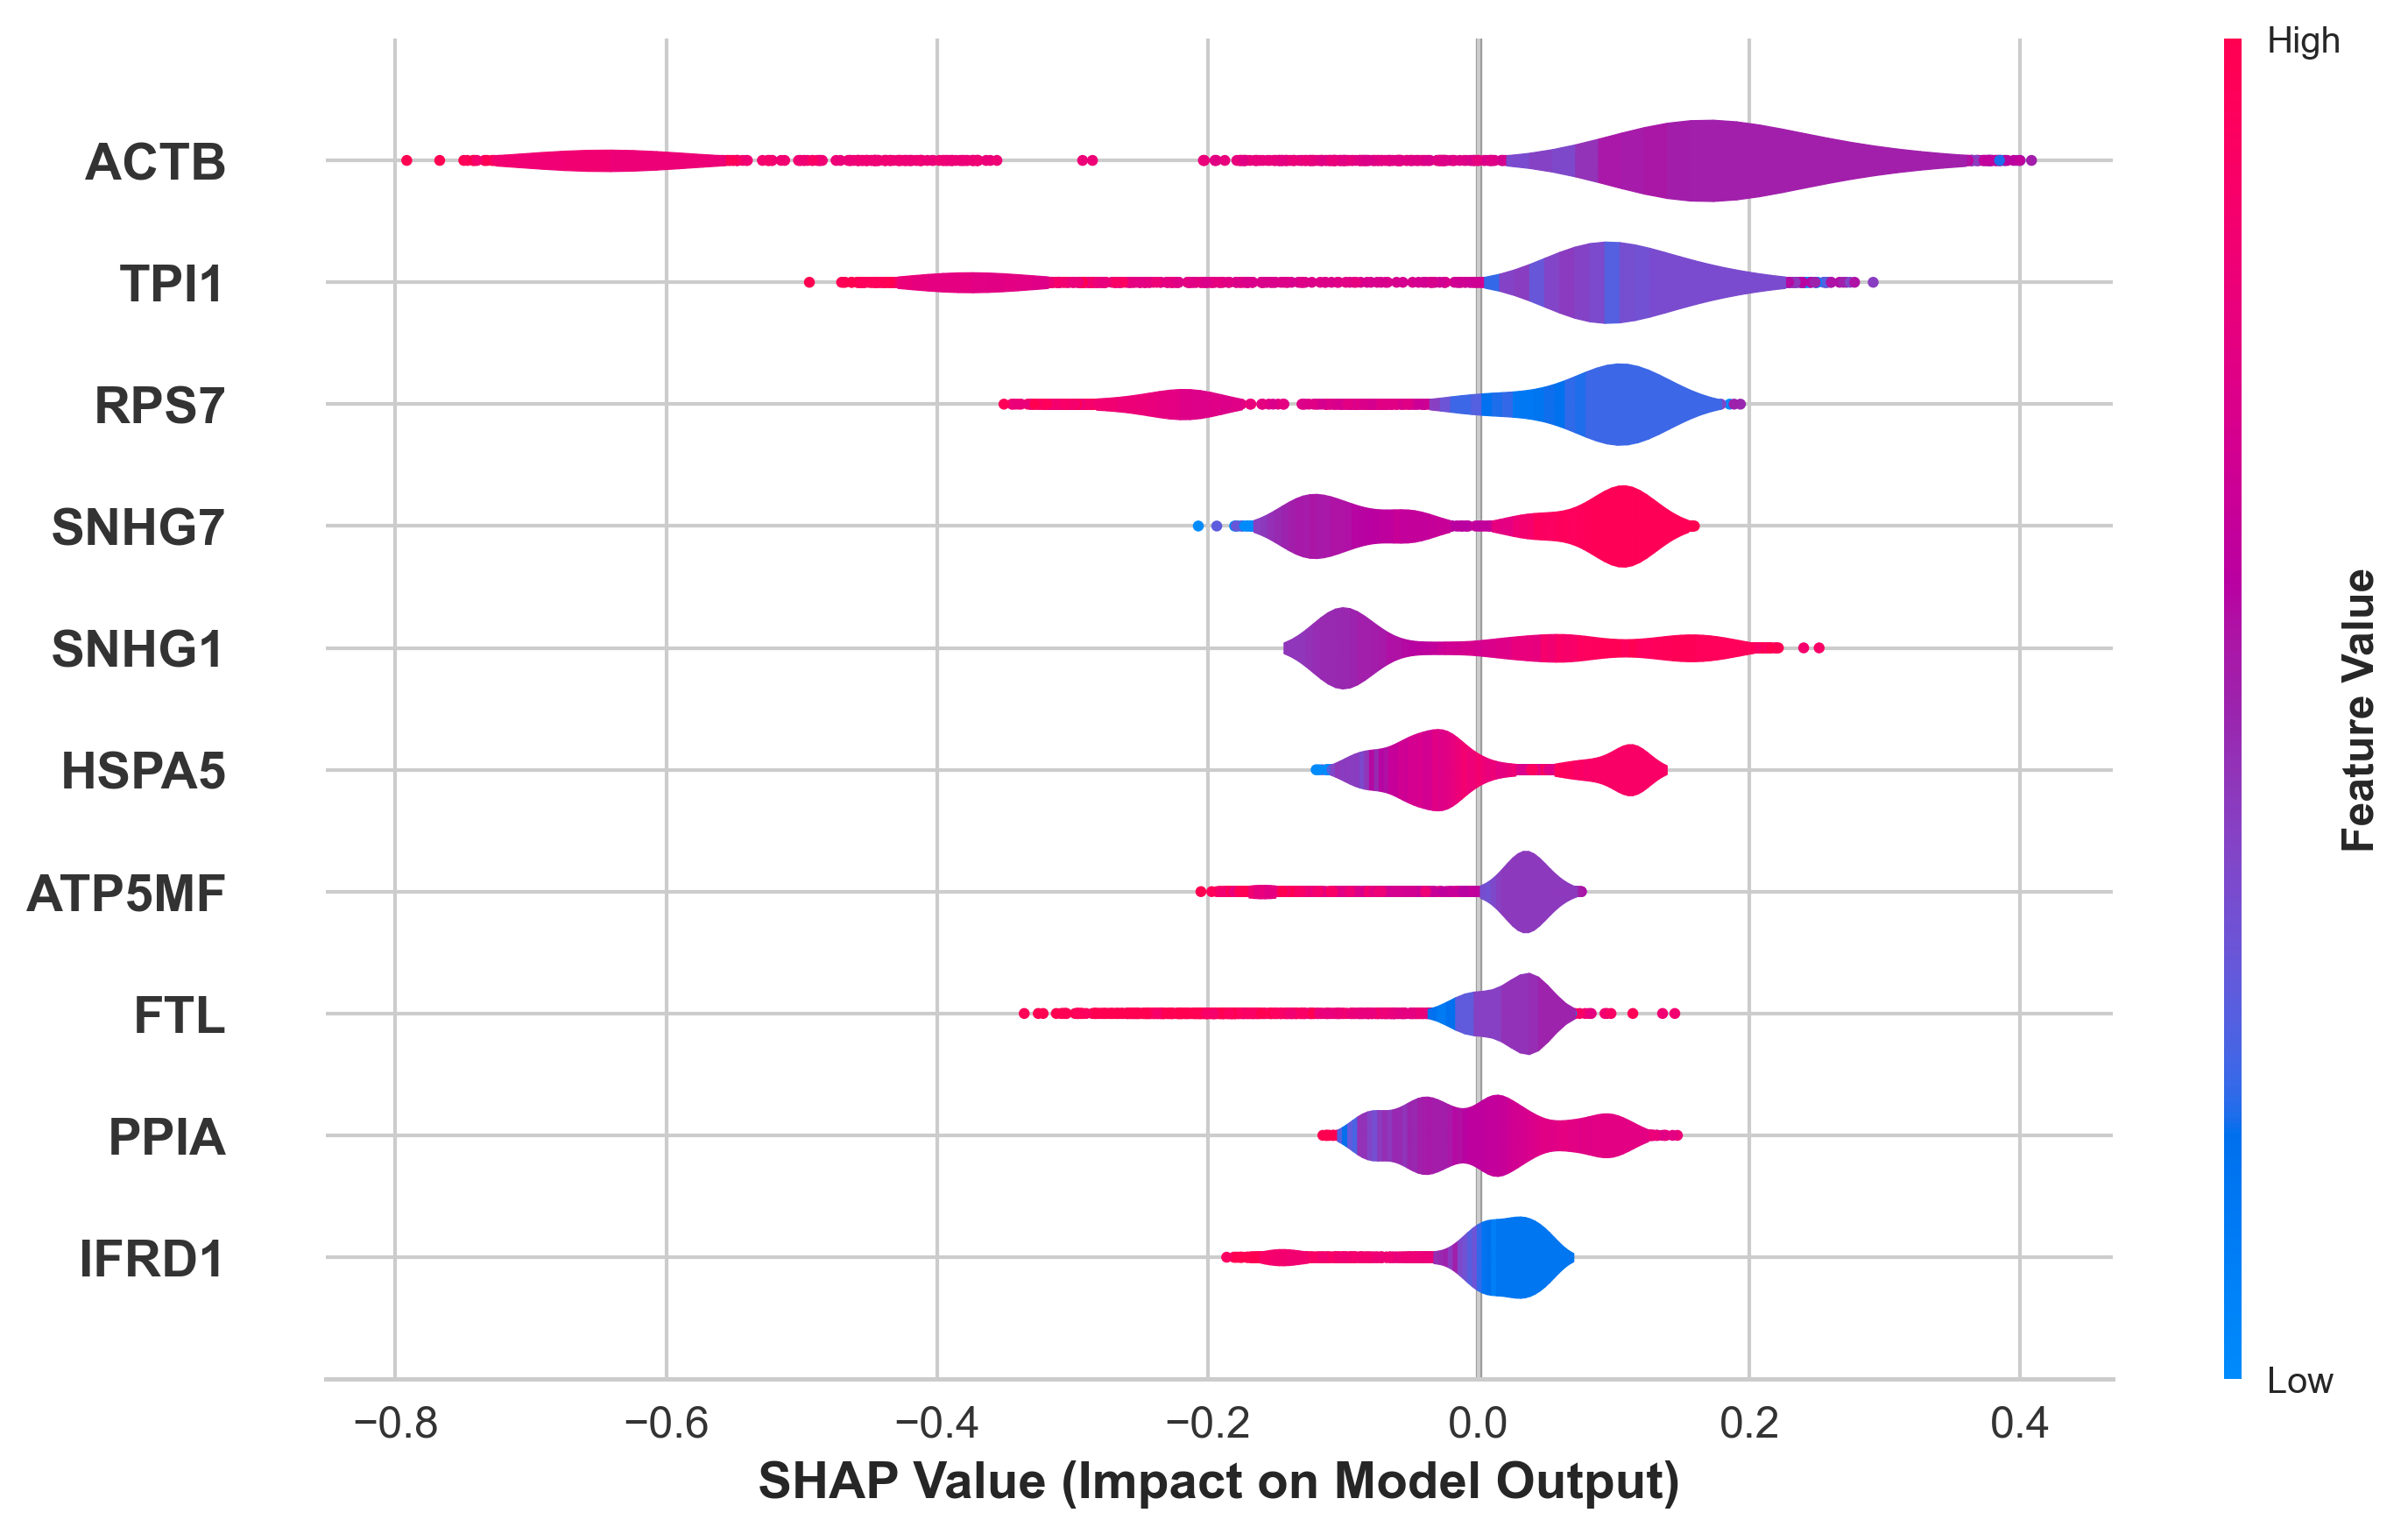

In [32]:
target_genes = ['ACTB','TPI1','FTL','RPS7','PPIA','SNHG1','SNHG7','IFRD1','HSPA5','ATP5MF']

pl.plot_shap_custom_features(
    shap_values=shap_values, 
    X_train=X_trans_df, 
    feature_names=feature_names, 
    target_features=target_genes, 
    plot_type="violin",
    save_path='./Plot/Figure1_Panel_D_SHAP_260421'
)

In [3]:
import sklearn, catboost, lightgbm, xgboost
import shap

print("scikit-learn:", sklearn.__version__)
print("catboost:", catboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)

scikit-learn: 1.4.2
catboost: 1.2.7
lightgbm: 4.5.0
xgboost: 2.1.4
shap: 0.44.1


In [4]:
import session_info

session_info.show()